# Chip Buddy EDA 분석

삼성전자(005930)·SK하이닉스(000660) 가격 데이터와 ESG 지표 데이터의 탐색적 데이터 분석(EDA)입니다.

- 가격: `data/processed/stock_prices.csv`, `data/processed/index_prices.csv`
- ESG: `data/processed/esg_indicators.csv`

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"  # Windows 한글 폰트 (matplotlib 기본 폰트는 한글 글리프 없음)
plt.rcParams["axes.unicode_minus"] = False  # Malgun Gothic 사용 시 마이너스 기호 깨짐 방지

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CHART_DIR = REPO_ROOT / "notebooks" / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

stock = pd.read_csv(REPO_ROOT / "data/processed/stock_prices.csv", dtype={"company_id": str, "ticker": str}, parse_dates=["date"])
index_px = pd.read_csv(REPO_ROOT / "data/processed/index_prices.csv", parse_dates=["date"])
esg = pd.read_csv(REPO_ROOT / "data/processed/esg_indicators.csv", dtype={"company_id": str})

COMPANY_NAMES = {"005930": "삼성전자", "000660": "SK하이닉스"}

print("stock_prices.csv:", stock.shape)
print("index_prices.csv:", index_px.shape)
print("esg_indicators.csv:", esg.shape)


stock_prices.csv: (1454, 15)
index_prices.csv: (750, 6)
esg_indicators.csv: (64, 28)


## 1. 가격 데이터 개요

데이터 크기, 기간, 컬럼 타입, 결측치·중복 여부를 확인합니다.

In [2]:
print("=== stock_prices.csv dtypes ===")
print(stock.dtypes)
print()
print("=== 기간 ===")
for cid, g in stock.groupby("company_id"):
    print(f"{COMPANY_NAMES[cid]}({cid}): {g['date'].min().date()} ~ {g['date'].max().date()}, {len(g)}거래일")
print()
print("=== 결측치 ===")
print(stock.isna().sum())
print()
print("=== 중복 (company_id, date) ===")
print(int(stock.duplicated(subset=["company_id", "date"]).sum()), "건")
print()
print("=== 두 종목 공통 거래일 ===")
dates_by_company = {cid: set(g["date"]) for cid, g in stock.groupby("company_id")}
common_dates = set.intersection(*dates_by_company.values())
print(len(common_dates), "일 (전체", stock["date"].nunique(), "일 중)")


=== stock_prices.csv dtypes ===
date              datetime64[ns]
company_id                object
company_name              object
ticker                    object
open                     float64
high                     float64
low                      float64
close                    float64
volume                     int64
adjusted_close           float64
currency                  object
source_type               object
source_url                object
data_status               object
note                      object
dtype: object

=== 기간 ===
SK하이닉스(000660): 2023-07-24 ~ 2026-07-21, 727거래일
삼성전자(005930): 2023-07-24 ~ 2026-07-21, 727거래일

=== 결측치 ===
date              0
company_id        0
company_name      0
ticker            0
open              0
high              0
low               0
close             0
volume            0
adjusted_close    0
currency          0
source_type       0
source_url        0
data_status       0
note              0
dtype: int64

=== 중복 (company_id, date) 

## 2. 종가·일별수익률 기초통계

`close` 기준 일별 로그수익률이 아닌 산술수익률(`pct_change`)을 사용합니다.

In [3]:
stock = stock.sort_values(["company_id", "date"]).reset_index(drop=True)
stock["daily_return"] = stock.groupby("company_id")["close"].pct_change()

returns_wide = stock.pivot(index="date", columns="company_id", values="daily_return").rename(columns=COMPANY_NAMES)
close_wide = stock.pivot(index="date", columns="company_id", values="close").rename(columns=COMPANY_NAMES)

print("=== 종가 기초통계 ===")
print(close_wide.describe())
print()
print("=== 일별수익률 기초통계 ===")
print(returns_wide.describe())


=== 종가 기초통계 ===
company_id        SK하이닉스           삼성전자
count       7.270000e+02     727.000000
mean        4.428077e+05  100422.008253
std         5.521114e+05   68788.995130
min         1.130000e+05   49900.000000
25%         1.675500e+05   61450.000000
50%         1.997000e+05   73100.000000
75%         4.835000e+05   97350.000000
max         2.919000e+06  362500.000000

=== 일별수익률 기초통계 ===
company_id      SK하이닉스        삼성전자
count       726.000000  726.000000
mean          0.004548    0.002169
std           0.038271    0.028363
min          -0.153670   -0.123055
25%          -0.014830   -0.011119
50%           0.001862    0.000000
75%           0.025799    0.014943
max           0.159079    0.144086


## 3. 수익률 히스토그램과 하위 5% 손실 분포

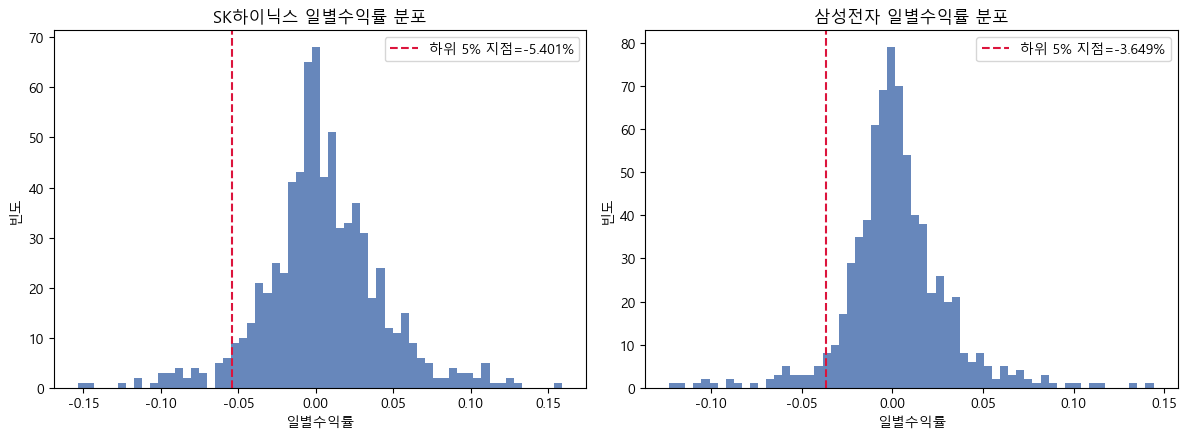

=== 하위 5% 손실 구간(VaR 95%, 부호는 손실이 음수) ===
SK하이닉스: VaR95%=-5.401%, 하위5% 평균손실(CVaR95%)=-8.381%, 표본수=37
삼성전자: VaR95%=-3.649%, 하위5% 평균손실(CVaR95%)=-6.438%, 표본수=37


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, returns_wide.columns):
    data = returns_wide[col].dropna()
    ax.hist(data, bins=60, color="#4C72B0", alpha=0.85)
    var95 = np.percentile(data, 5)
    ax.axvline(var95, color="crimson", linestyle="--", label=f"하위 5% 지점={var95:.3%}")
    ax.set_title(f"{col} 일별수익률 분포")
    ax.set_xlabel("일별수익률")
    ax.set_ylabel("빈도")
    ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "01_return_histogram.png", dpi=150)
plt.show()

print("=== 하위 5% 손실 구간(VaR 95%, 부호는 손실이 음수) ===")
for col in returns_wide.columns:
    data = returns_wide[col].dropna()
    tail = data[data <= np.percentile(data, 5)]
    print(f"{col}: VaR95%={np.percentile(data, 5):.3%}, 하위5% 평균손실(CVaR95%)={tail.mean():.3%}, 표본수={len(tail)}")


## 4. 누적수익률 차트

전체 기간(2023-07-21~) 기준 100을 시작점으로 정규화한 누적수익률입니다. 반도체 지수(SOX)와 함께 비교합니다.

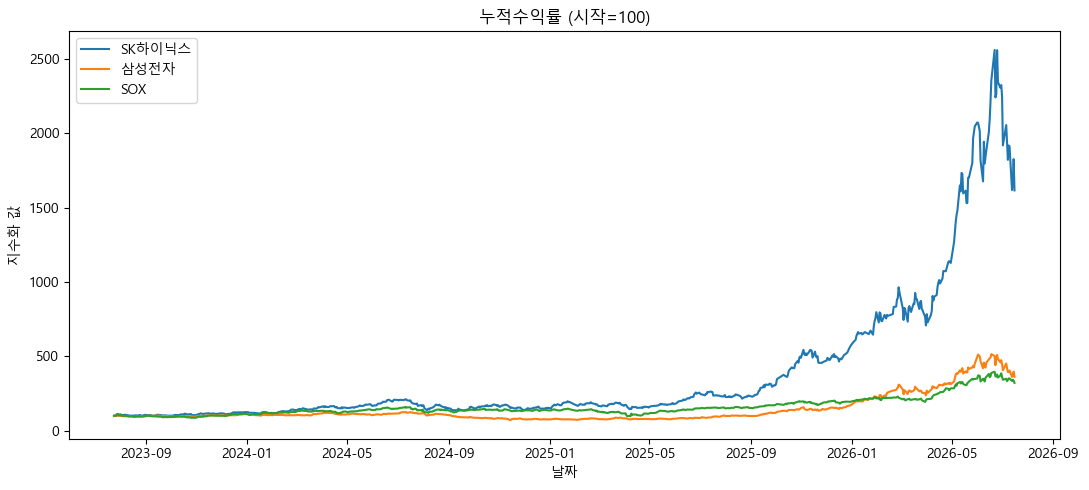

=== 전체 기간 총 누적수익률 ===
SK하이닉스    1515.8%
삼성전자       262.2%
SOX        221.4%
dtype: object


In [5]:
index_sox = index_px[index_px["index_id"] == "SOX"].set_index("date")["close"].rename("SOX")

combined = close_wide.join(index_sox, how="inner")
cumret = combined / combined.iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 5))
for col in cumret.columns:
    ax.plot(cumret.index, cumret[col], label=col)
ax.set_title("누적수익률 (시작=100)")
ax.set_xlabel("날짜")
ax.set_ylabel("지수화 값")
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "02_cumulative_return.png", dpi=150)
plt.show()

print("=== 전체 기간 총 누적수익률 ===")
print((cumret.iloc[-1] / cumret.iloc[0] - 1).map(lambda x: f"{x:.1%}"))


## 5. 최대 낙폭(MDD) 구간

SK하이닉스: MDD=-39.6%, 고점=2026-06-22, 저점=2026-07-20, 회복일=미회복
삼성전자: MDD=-43.2%, 고점=2024-07-09, 저점=2024-11-14, 회복일=2025-10-02


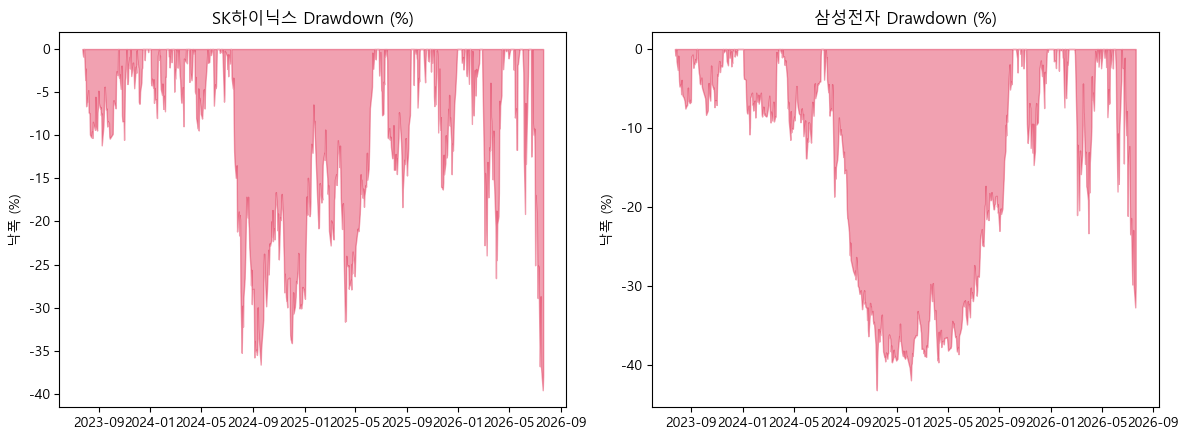

In [6]:
def max_drawdown(series: pd.Series) -> dict:
    running_max = series.cummax()
    drawdown = series / running_max - 1
    trough_date = drawdown.idxmin()
    peak_date = series.loc[:trough_date].idxmax()
    mdd = drawdown.min()
    # 회복일: trough 이후 처음으로 peak 수준을 다시 넘은 날짜
    after_trough = series.loc[trough_date:]
    recovery = after_trough[after_trough >= series.loc[peak_date]]
    recovery_date = recovery.index[0] if len(recovery) else None
    return {"peak_date": peak_date, "trough_date": trough_date, "mdd": mdd, "recovery_date": recovery_date}


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, close_wide.columns):
    series = close_wide[col].dropna()
    running_max = series.cummax()
    drawdown = series / running_max - 1
    ax.fill_between(drawdown.index, drawdown.values * 100, 0, color="crimson", alpha=0.4)
    ax.set_title(f"{col} Drawdown (%)")
    ax.set_ylabel("낙폭 (%)")
    info = max_drawdown(series)
    print(f"{col}: MDD={info['mdd']:.1%}, 고점={info['peak_date'].date()}, 저점={info['trough_date'].date()}, "
          f"회복일={info['recovery_date'].date() if info['recovery_date'] is not None else '미회복'}")
fig.tight_layout()
fig.savefig(CHART_DIR / "03_drawdown.png", dpi=150)
plt.show()


## 6. 두 종목 수익률 상관관계

=== 일별수익률 상관계수 ===
company_id    SK하이닉스      삼성전자
company_id                    
SK하이닉스      1.000000  0.687657
삼성전자        0.687657  1.000000


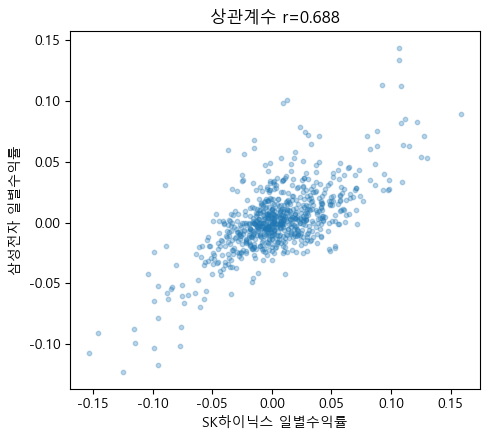

In [7]:
corr = returns_wide.corr()
print("=== 일별수익률 상관계수 ===")
print(corr)

fig, ax = plt.subplots(figsize=(5, 4.5))
cols = returns_wide.dropna().columns
x, y = returns_wide.dropna()[cols[0]], returns_wide.dropna()[cols[1]]
ax.scatter(x, y, alpha=0.3, s=10)
ax.set_xlabel(f"{cols[0]} 일별수익률")
ax.set_ylabel(f"{cols[1]} 일별수익률")
r = corr.iloc[0, 1]
ax.set_title(f"상관계수 r={r:.3f}")
fig.tight_layout()
fig.savefig(CHART_DIR / "04_correlation_scatter.png", dpi=150)
plt.show()


## 7. 1년·3년 기간별 CVaR 비교용 데이터

데이터 B가 최종 CVaR 95%를 계산할 기간(최근 1년 vs 전체~3년)을 정할 때 참고할 수 있도록, 각 구간별 CVaR 95%를 미리 비교합니다.

In [8]:
def cvar_95(series: pd.Series) -> float:
    series = series.dropna()
    var95 = np.percentile(series, 5)
    tail = series[series <= var95]
    return tail.mean()


last_date = returns_wide.index.max()
windows = {
    "최근 1년": last_date - pd.DateOffset(years=1),
    "전체(~3년)": returns_wide.index.min(),
}

rows = []
for label, start in windows.items():
    sub = returns_wide.loc[returns_wide.index >= start]
    for col in sub.columns:
        rows.append({
            "구간": label,
            "종목": col,
            "표본일수": sub[col].dropna().shape[0],
            "연환산 변동성": sub[col].std() * np.sqrt(252),
            "CVaR95%(일별)": cvar_95(sub[col]),
        })

cvar_compare = pd.DataFrame(rows)
cvar_compare["연환산 변동성"] = cvar_compare["연환산 변동성"].map(lambda x: f"{x:.1%}")
cvar_compare["CVaR95%(일별)"] = cvar_compare["CVaR95%(일별)"].map(lambda x: f"{x:.3%}")
print(cvar_compare.to_string(index=False))


     구간     종목  표본일수 연환산 변동성 CVaR95%(일별)
  최근 1년 SK하이닉스   244   80.5%    -10.496%
  최근 1년   삼성전자   244   65.3%     -8.865%
전체(~3년) SK하이닉스   726   60.8%     -8.381%
전체(~3년)   삼성전자   726   45.0%     -6.438%


## 8. ESG 지표 데이터 개요

`esg_indicators.csv`의 크기·결측·중복을 확인하고, 카테고리(E/S/G)·신뢰도(`data_confidence`)·위험방향(`risk_direction`) 분포를 봅니다.

In [9]:
print("=== 크기/기간 ===")
print(esg.shape, "| period 범위:", esg["period"].min(), "~", esg["period"].max())
print()
print("=== 결측치(주요 열) ===")
print(esg[["raw_value", "target_value", "baseline_value", "source_page"]].isna().sum())
print()
print("=== 중복(company_id, indicator_id, period) ===")
print(int(esg.duplicated(subset=["company_id", "indicator_id", "period"]).sum()), "건")
print()
print("=== 카테고리(E/S/G)별 행 수 ===")
print(esg["category"].value_counts())
print()
print("=== 기업×지표 행 수 ===")
print(esg.groupby(["company_id", "indicator_id"]).size().unstack(fill_value=0))


=== 크기/기간 ===
(64, 28) | period 범위: 2020 ~ 2026

=== 결측치(주요 열) ===
raw_value          0
target_value      55
baseline_value    58
source_page        0
dtype: int64

=== 중복(company_id, indicator_id, period) ===
1 건

=== 카테고리(E/S/G)별 행 수 ===
category
E    38
S    23
G     3
Name: count, dtype: int64

=== 기업×지표 행 수 ===
indicator_id  E01  E02  E03  E04  E05  G01  G03  S01  S02  S03  S04  S05
company_id                                                              
000660          6    6    6    3    2    0    0    1    1    5    4    1
005930          5    3    3    2    2    2    1    4    3    3    1    0


## 9. ESG 노출도·관리수준·불확실성 분포

이 데이터셋은 `exposure`/`management`/`data_uncertainty` 점수 컬럼 대신 `risk_direction`(위험방향)·`data_confidence`(신뢰도)·`scope_mismatch`(범위 불일치)로 관리 수준·불확실성을 표현합니다.

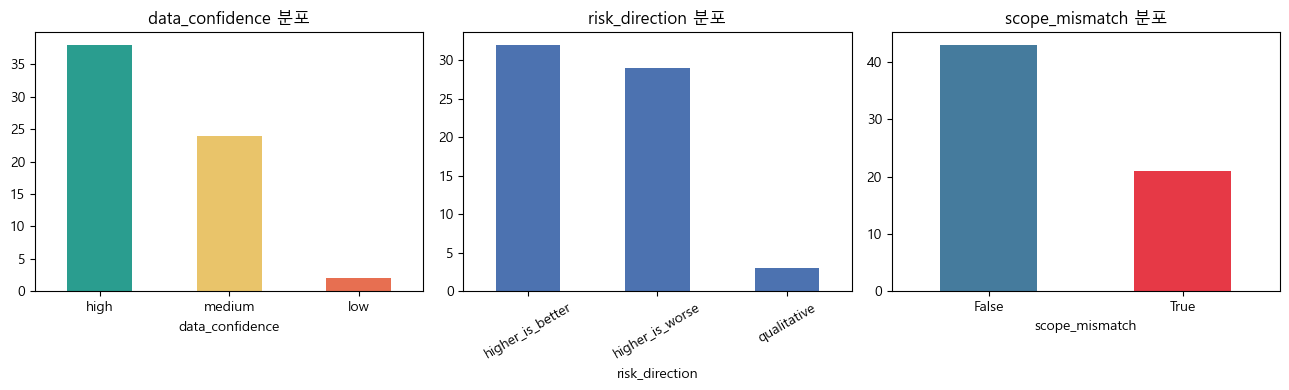

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

esg["data_confidence"].value_counts().reindex(["high", "medium", "low"]).plot(
    kind="bar", ax=axes[0], color=["#2a9d8f", "#e9c46a", "#e76f51"]
)
axes[0].set_title("data_confidence 분포")
axes[0].tick_params(axis="x", rotation=0)

esg["risk_direction"].value_counts().plot(kind="bar", ax=axes[1], color="#4C72B0")
axes[1].set_title("risk_direction 분포")
axes[1].tick_params(axis="x", rotation=30)

esg["scope_mismatch"].value_counts().plot(kind="bar", ax=axes[2], color=["#457b9d", "#e63946"])
axes[2].set_title("scope_mismatch 분포")
axes[2].tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig(CHART_DIR / "05_esg_distribution.png", dpi=150)
plt.show()


## 10. 사업범위 불일치·낮은 신뢰도 항목 목록

기업 간 직접 비교나 평균에 쓰면 안 되는 행들을 모아둡니다(`data/docs/indicator_comparability.csv`의 `not_comparable`/`one_sided` 분류와 함께 참고).

In [11]:
cols = ["company_id", "company_name", "indicator_id", "period", "business_scope", "data_confidence"]

print(f"=== scope_mismatch=true ({int((esg['scope_mismatch'] == True).sum())}행) ===")
print(esg.loc[esg["scope_mismatch"] == True, cols].to_string(index=False))
print()
print(f"=== data_confidence=low ({int((esg['data_confidence'] == 'low').sum())}행) ===")
low_conf = esg.loc[esg["data_confidence"] == "low", cols]
print(low_conf.to_string(index=False) if len(low_conf) else "(없음)")


=== scope_mismatch=true (21행) ===
company_id company_name indicator_id  period business_scope data_confidence
    005930         삼성전자          E01    2021   consolidated            high
    005930         삼성전자          E01    2022   consolidated            high
    005930         삼성전자          E01    2023   consolidated            high
    005930         삼성전자          E01    2024   consolidated            high
    005930         삼성전자          E01    2025   consolidated            high
    005930         삼성전자          E05    2024   consolidated            high
    005930         삼성전자          E05    2025   consolidated            high
    005930         삼성전자          S01    2022   consolidated            high
    005930         삼성전자          S01    2023   consolidated            high
    005930         삼성전자          S01    2024   consolidated            high
    005930         삼성전자          S01    2025   consolidated            high
    005930         삼성전자          S02    2023   consoli

## 11. EDA 결론 요약

### 가격 데이터

- **품질**: 2023-07-24~2026-07-21, 삼성전자·SK하이닉스 각 727거래일. 결측·중복 0건, 두 종목 공통거래일 727/727(100%)로 CVaR·상관관계 계산에 결측 보정이 필요 없다.
- **수익률 특성**: SK하이닉스가 삼성전자보다 변동성이 훨씬 크다(일별수익률 표준편차 3.83% vs 2.84%, 연환산 변동성 전체기간 60.8% vs 45.0%). 하위 5% 손실 구간의 평균손실(CVaR95%, 일별)도 SK하이닉스 -8.38%, 삼성전자 -6.44%로 SK하이닉스의 하방위험이 더 크다.
- **누적수익률**: 전체 기간 SK하이닉스 +1,515.8%, 삼성전자 +262.2%, SOX 지수 +221.4%. SK하이닉스의 초과 상승이 두드러지며(2026년 상반기 HBM/AI 메모리 수요 급등 구간과 일치), 이 때문에 포트폴리오 비중이 편중된 사용자는 실제 위험 노출도 그만큼 커진다.
- **최대낙폭(MDD)**: 삼성전자 -43.2%(2024-07-09 고점→2024-11-14 저점, 2025-10-02 회복, 회복까지 약 15개월). SK하이닉스 -39.6%(2026-06-22 고점→2026-07-20 저점, **아직 미회복** — 데이터 마감 시점 기준 최근 낙폭 진행 중이므로 회복일 필드는 null로 처리해야 한다).
- **상관관계**: 두 종목 일별수익률 상관계수 0.688로 중간~높은 양의 상관관계. 두 종목을 같이 보유해도 분산효과가 제한적일 수 있음을 시사한다(포트폴리오 20~80% 제약의 근거 중 하나로 참고 가능).
- **1년 vs 3년 CVaR 비교(데이터 B 참고용)**: 최근 1년 구간이 전체 구간보다 변동성·CVaR이 뚜렷하게 크다(SK하이닉스 CVaR95% -10.50%(1년) vs -8.38%(전체), 삼성전자 -8.87%(1년) vs -6.44%(전체)). **어느 구간을 CVaR 계산 기준으로 쓸지에 따라 위험 추정치가 크게 달라지므로, Data B와 기간 합의가 필요하다.**

### ESG 데이터

- **구조**: 64행, 2020~2026년 12개 지표(E01~E05, S01~S05, G01, G03 — G02는 행 자체가 없음), 카테고리별 E 38행/S 23행/G 3행.
- **결측**: `target_value` 55행, `baseline_value` 58행이 결측인데, 이는 원문에서 지표 정의와 정확히 일치하는 수치 목표를 찾은 2개 지표(SK E01, 삼성 E03)에만 목표값을 채웠기 때문에 의도된 결측이다(임의 채움 아님).
- **"중복" 1건은 실제로는 정상**: `(company_id, indicator_id, period)` 기준 자동 중복 검사에서 SK하이닉스 E05·2025년에 2행이 걸리는데, 이는 SK의 E05가 "환경법규 위반 건수"와 "대기오염물질 총배출량" 두 하위 지표를 함께 담고 있어서다(삼성 유출건수에 대응하는 단일 지표가 SK 보고서에 없어 두 값으로 대체). 지표 정의 문서(`data_dictionary.md`)에 이미 근거가 남아있다.
- **범위 불일치**: `scope_mismatch=true` 21행이 전부 삼성전자(DX+DS 연결 기준 사용 지표: E01, E05, S01~S04, G01, G03)에 몰려있다. SK하이닉스는 사실상 반도체 단일사업이라 이 플래그가 전혀 없다.
- **낮은 신뢰도**: `data_confidence=low` 2행은 삼성전자 E04(공정가스 처리효율, DS부문, 2024·2025)로, SK의 "전사 배출감소율" 단일지표와 정의가 달라(`not_comparable`) 신뢰도를 낮게 책정했다.

### 모델링 시 주의사항 (Data B 전달)

1. CVaR 계산 기준 기간(1년 vs 3년 전체)을 먼저 합의할 것 — 결과가 상당히 달라짐
2. `scope_mismatch=true` 21행(전부 삼성)은 UI에 "연결 기준" 경고 표시 필요
3. SK E05의 두 하위값(위반건수/배출량)을 하나의 스칼라로 집계할 때 이중계산 주의
4. `not_comparable`/`one_sided` 지표(E02, E04, E05, S04, S05, G01, G03)는 기업 간 평균·상대비교 금지(`data/docs/indicator_comparability.csv` 참고)